<a href="https://www.kaggle.com/code/sonawanelalitsunil/kidney-disease-dataset-ml-80-23?scriptVersionId=234323933" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/kidney-disease-dataset/kidney_disease_dataset.csv


### Title: Kidney Disease Dataset

## Description:
A medical dataset containing patient records with clinical, demographic, and laboratory data to support kidney disease detection and analysis.

In [2]:
df = pd.read_csv('/kaggle/input/kidney-disease-dataset/kidney_disease_dataset.csv')

In [3]:
df.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease


In [4]:
df.tail()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
20533,86,113,1.008,5,3,normal,abnormal,not present,not present,473,...,no,38.2,low,25,1,2.77,normal,2.45,9.31,No_Disease
20534,47,80,1.016,3,4,normal,abnormal,not present,not present,477,...,no,26.8,moderate,3,7,1.81,normal,4.19,3.45,No_Disease
20535,89,178,1.011,3,5,abnormal,abnormal,not present,not present,141,...,yes,30.0,low,6,25,1.32,abnormal,5.32,8.39,No_Disease
20536,86,138,1.009,1,5,abnormal,normal,not present,present,110,...,yes,28.9,low,0,21,2.52,abnormal,0.61,9.53,No_Disease
20537,63,120,1.015,4,5,abnormal,abnormal,present,not present,256,...,no,36.7,moderate,3,28,1.03,normal,7.00,2.36,No_Disease


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20538 entries, 0 to 20537
Data columns (total 43 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age of the patient                           20538 non-null  int64  
 1   Blood pressure (mm/Hg)                       20538 non-null  int64  
 2   Specific gravity of urine                    20538 non-null  float64
 3   Albumin in urine                             20538 non-null  int64  
 4   Sugar in urine                               20538 non-null  int64  
 5   Red blood cells in urine                     20538 non-null  object 
 6   Pus cells in urine                           20538 non-null  object 
 7   Pus cell clumps in urine                     20538 non-null  object 
 8   Bacteria in urine                            20538 non-null  object 
 9   Random blood glucose level (mg/dl)           20538 non-null  int64  
 10

In [6]:
df.describe()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Random blood glucose level (mg/dl),Blood urea (mg/dl),Serum creatinine (mg/dl),Sodium level (mEq/L),Potassium level (mEq/L),...,Cholesterol level,Parathyroid hormone (PTH) level,Serum calcium level,Serum phosphate level,Body Mass Index (BMI),Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level
count,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,...,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000
mean,47.477895,130.352079,1.015041,2.501266,2.494595,284.630295,104.094240,7.781865,135.076646,4.992314,...,200.236440,40.265400,9.001840,4.241157,27.544240,14.918152,14.946879,1.749459,5.061633,7.702504
std,24.941947,29.063838,0.005793,1.697084,1.701059,124.633265,55.726482,4.179925,8.651000,0.871026,...,57.863374,17.310488,0.867301,1.006735,7.221082,8.963722,8.945500,0.718980,2.853217,4.191765
min,5.000000,80.000000,1.005000,0.000000,0.000000,70.000000,7.002370,0.500000,120.000613,3.500005,...,100.000000,10.000045,7.500000,2.500000,15.000000,0.000000,0.000000,0.500000,0.100000,0.500000
25%,26.000000,105.000000,1.010000,1.000000,1.000000,176.000000,55.864665,4.200000,127.563468,4.229885,...,150.000000,25.396841,8.250000,3.380000,21.300000,7.000000,7.000000,1.130000,2.600000,4.050000
50%,47.000000,131.000000,1.015000,3.000000,2.000000,284.500000,104.401355,7.780000,135.044974,4.990991,...,200.000000,40.423386,8.990000,4.230000,27.600000,15.000000,15.000000,1.750000,5.070000,7.710000
75%,69.000000,156.000000,1.020000,4.000000,4.000000,393.000000,152.480048,11.430000,142.607311,5.749899,...,250.000000,55.272665,9.750000,5.110000,33.800000,23.000000,23.000000,2.370000,7.537500,11.297500
max,90.000000,180.000000,1.025000,5.000000,5.000000,500.000000,199.994361,15.000000,149.999914,6.499827,...,300.000000,69.999871,10.500000,6.000000,40.000000,30.000000,30.000000,3.000000,10.000000,15.000000


In [7]:
df.isnull().sum()

Age of the patient                             0
Blood pressure (mm/Hg)                         0
Specific gravity of urine                      0
Albumin in urine                               0
Sugar in urine                                 0
Red blood cells in urine                       0
Pus cells in urine                             0
Pus cell clumps in urine                       0
Bacteria in urine                              0
Random blood glucose level (mg/dl)             0
Blood urea (mg/dl)                             0
Serum creatinine (mg/dl)                       0
Sodium level (mEq/L)                           0
Potassium level (mEq/L)                        0
Hemoglobin level (gms)                         0
Packed cell volume (%)                         0
White blood cell count (cells/cumm)            0
Red blood cell count (millions/cumm)           0
Hypertension (yes/no)                          0
Diabetes mellitus (yes/no)                     0
Coronary artery dise

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Age of the patient                               int64
Blood pressure (mm/Hg)                           int64
Specific gravity of urine                      float64
Albumin in urine                                 int64
Sugar in urine                                   int64
Red blood cells in urine                        object
Pus cells in urine                              object
Pus cell clumps in urine                        object
Bacteria in urine                               object
Random blood glucose level (mg/dl)               int64
Blood urea (mg/dl)                             float64
Serum creatinine (mg/dl)                       float64
Sodium level (mEq/L)                           float64
Potassium level (mEq/L)                        float64
Hemoglobin level (gms)                         float64
Packed cell volume (%)                           int64
White blood cell count (cells/cumm)              int64
Red blood cell count (millions/cumm)           float64
Hypertensi

In [10]:
df.shape

(20538, 43)

In [11]:
df.columns

Index(['Age of the patient', 'Blood pressure (mm/Hg)',
       'Specific gravity of urine', 'Albumin in urine', 'Sugar in urine',
       'Red blood cells in urine', 'Pus cells in urine',
       'Pus cell clumps in urine', 'Bacteria in urine',
       'Random blood glucose level (mg/dl)', 'Blood urea (mg/dl)',
       'Serum creatinine (mg/dl)', 'Sodium level (mEq/L)',
       'Potassium level (mEq/L)', 'Hemoglobin level (gms)',
       'Packed cell volume (%)', 'White blood cell count (cells/cumm)',
       'Red blood cell count (millions/cumm)', 'Hypertension (yes/no)',
       'Diabetes mellitus (yes/no)', 'Coronary artery disease (yes/no)',
       'Appetite (good/poor)', 'Pedal edema (yes/no)', 'Anemia (yes/no)',
       'Estimated Glomerular Filtration Rate (eGFR)',
       'Urine protein-to-creatinine ratio', 'Urine output (ml/day)',
       'Serum albumin level', 'Cholesterol level',
       'Parathyroid hormone (PTH) level', 'Serum calcium level',
       'Serum phosphate level', 'Family hi

## Data visualizatons

<Axes: xlabel='Serum creatinine (mg/dl)', ylabel='Count'>

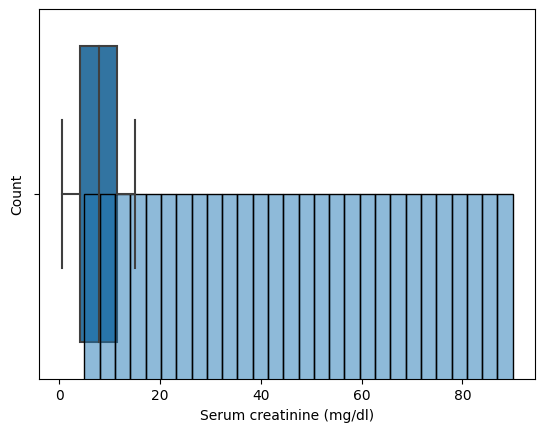

In [12]:
sns.histplot(df['Age of the patient'], kde=True)
sns.boxplot(x=df['Serum creatinine (mg/dl)'])

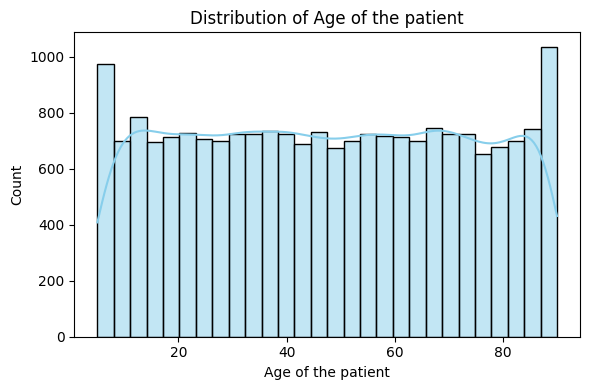

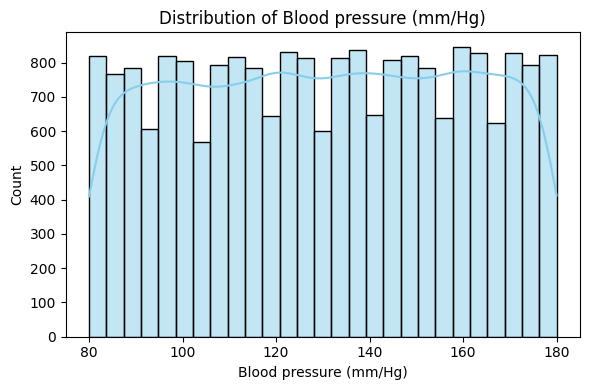

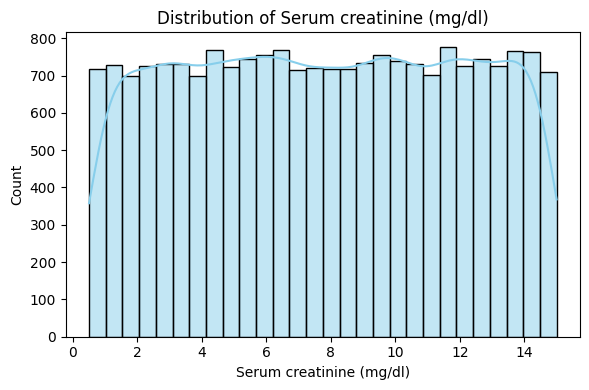

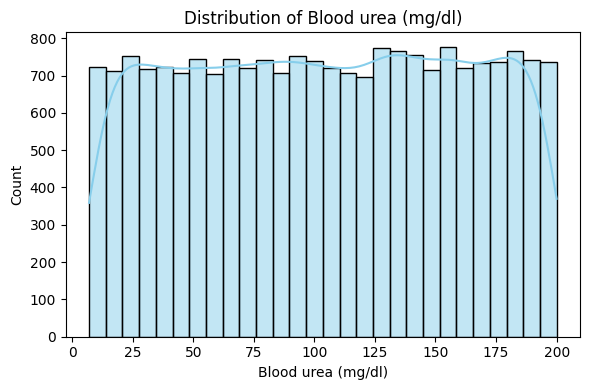

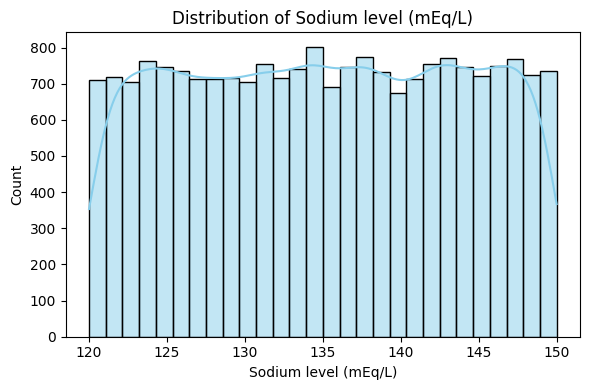

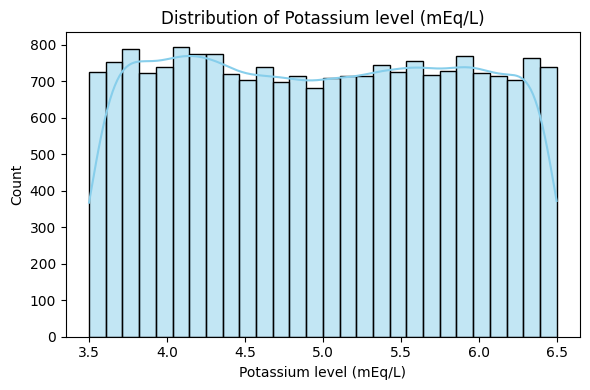

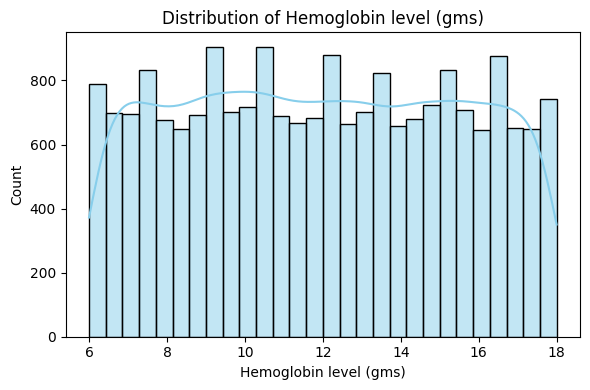

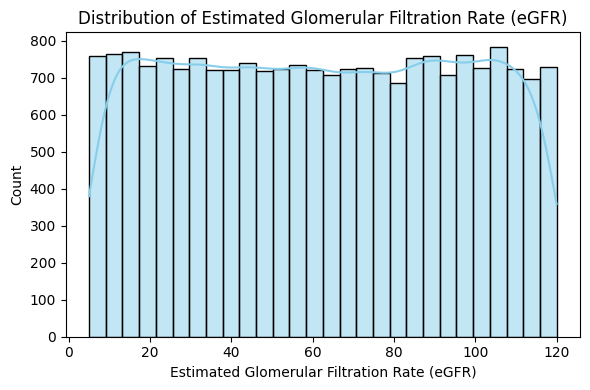

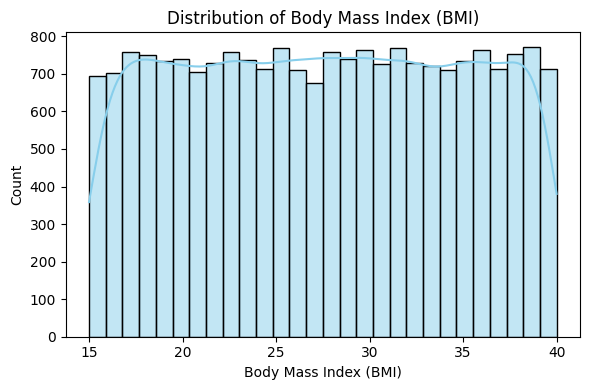

In [13]:
numerical_cols = [
    'Age of the patient', 'Blood pressure (mm/Hg)', 'Serum creatinine (mg/dl)',
    'Blood urea (mg/dl)', 'Sodium level (mEq/L)', 'Potassium level (mEq/L)',
    'Hemoglobin level (gms)', 'Estimated Glomerular Filtration Rate (eGFR)', 
    'Body Mass Index (BMI)'
]

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


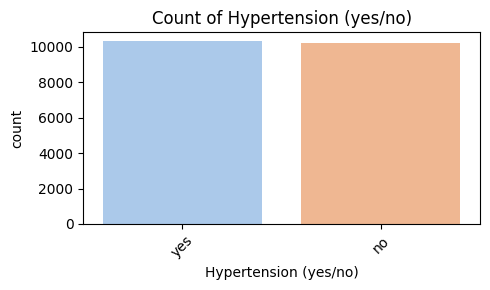

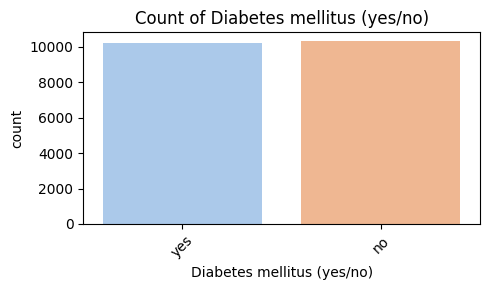

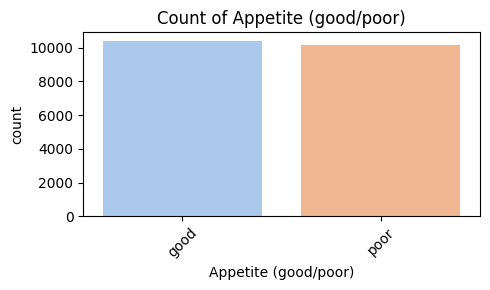

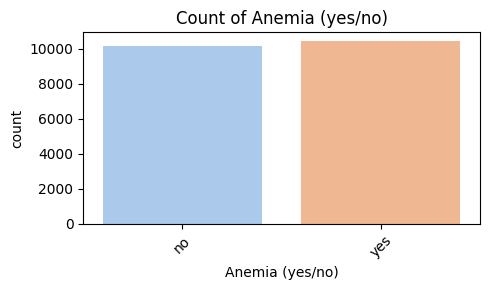

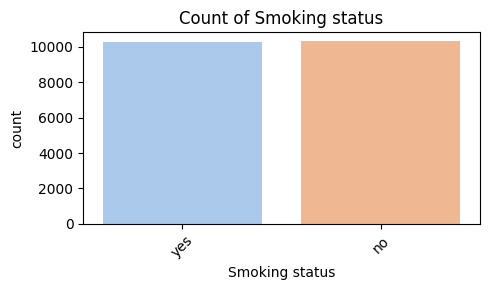

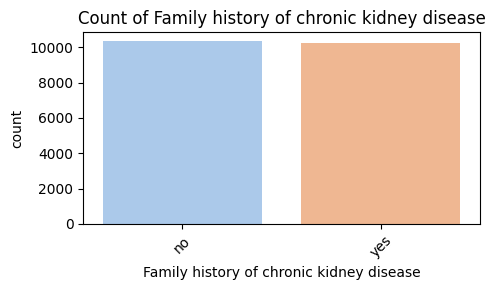

In [14]:
categorical_cols = [
    'Hypertension (yes/no)', 'Diabetes mellitus (yes/no)', 'Appetite (good/poor)',
    'Anemia (yes/no)', 'Smoking status', 'Family history of chronic kidney disease'
]

for col in categorical_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=col, data=df, palette='pastel')
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


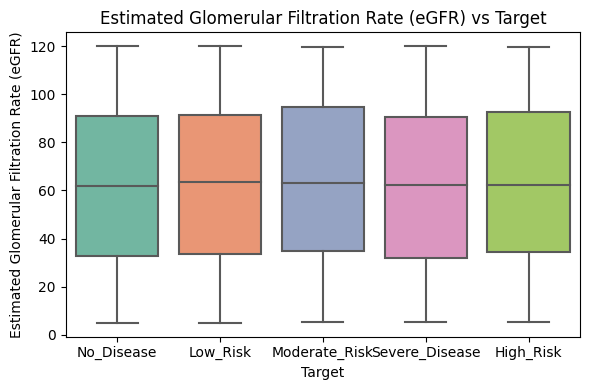

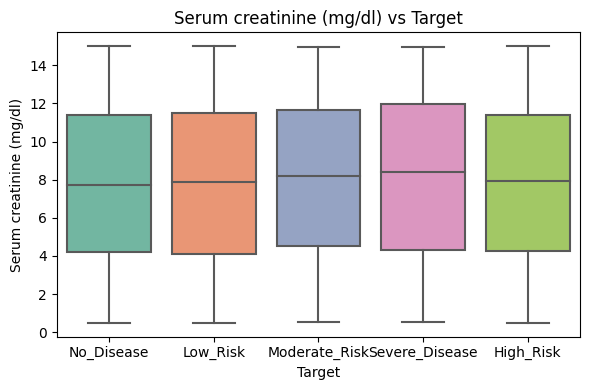

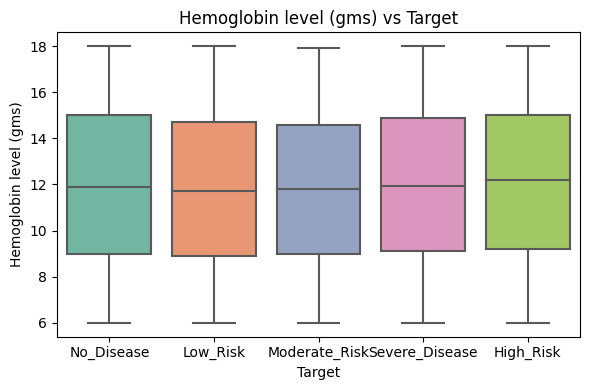

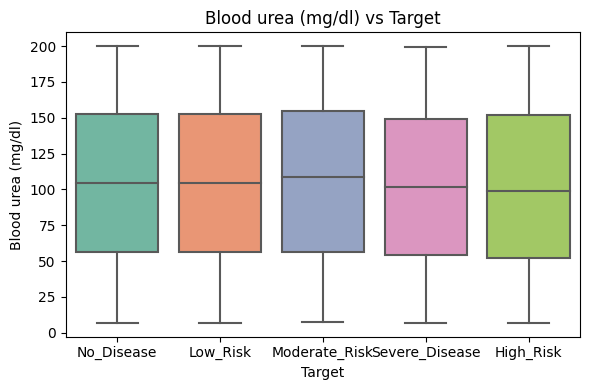

In [15]:
target = 'Target'  # make sure the target column is set

important_features = [
    'Estimated Glomerular Filtration Rate (eGFR)',
    'Serum creatinine (mg/dl)',
    'Hemoglobin level (gms)',
    'Blood urea (mg/dl)'
]

for col in important_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=target, y=col, data=df, palette='Set2')
    plt.title(f'{col} vs {target}')
    plt.tight_layout()
    plt.show()

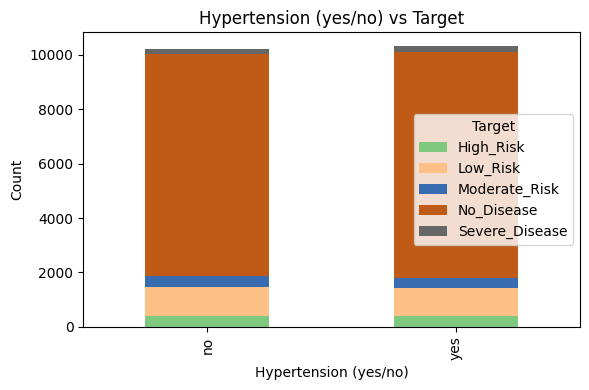

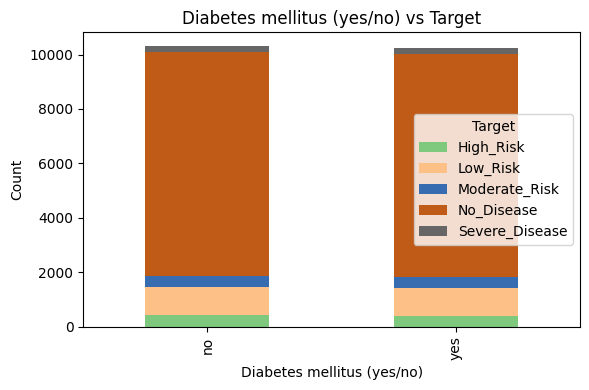

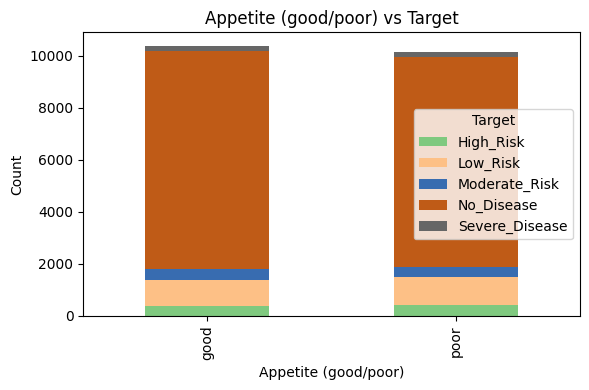

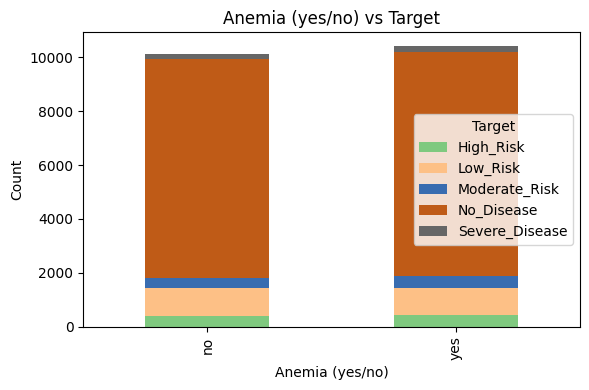

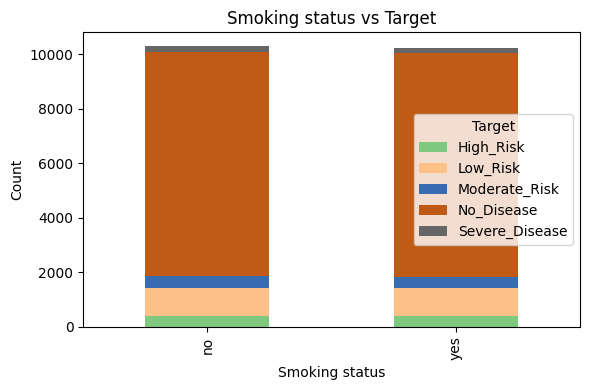

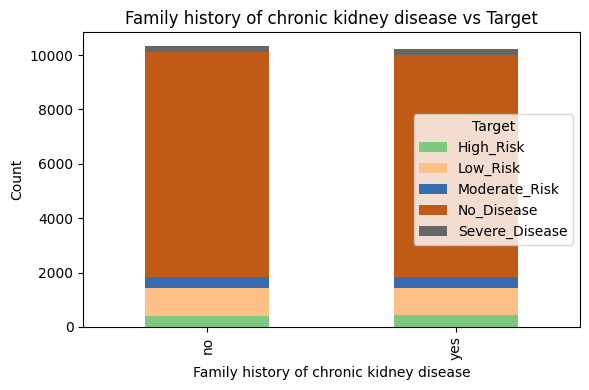

In [16]:
for col in categorical_cols:
    pd.crosstab(df[col], df[target]).plot(kind='bar', stacked=True, figsize=(6, 4), colormap='Accent')
    plt.title(f'{col} vs {target}')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


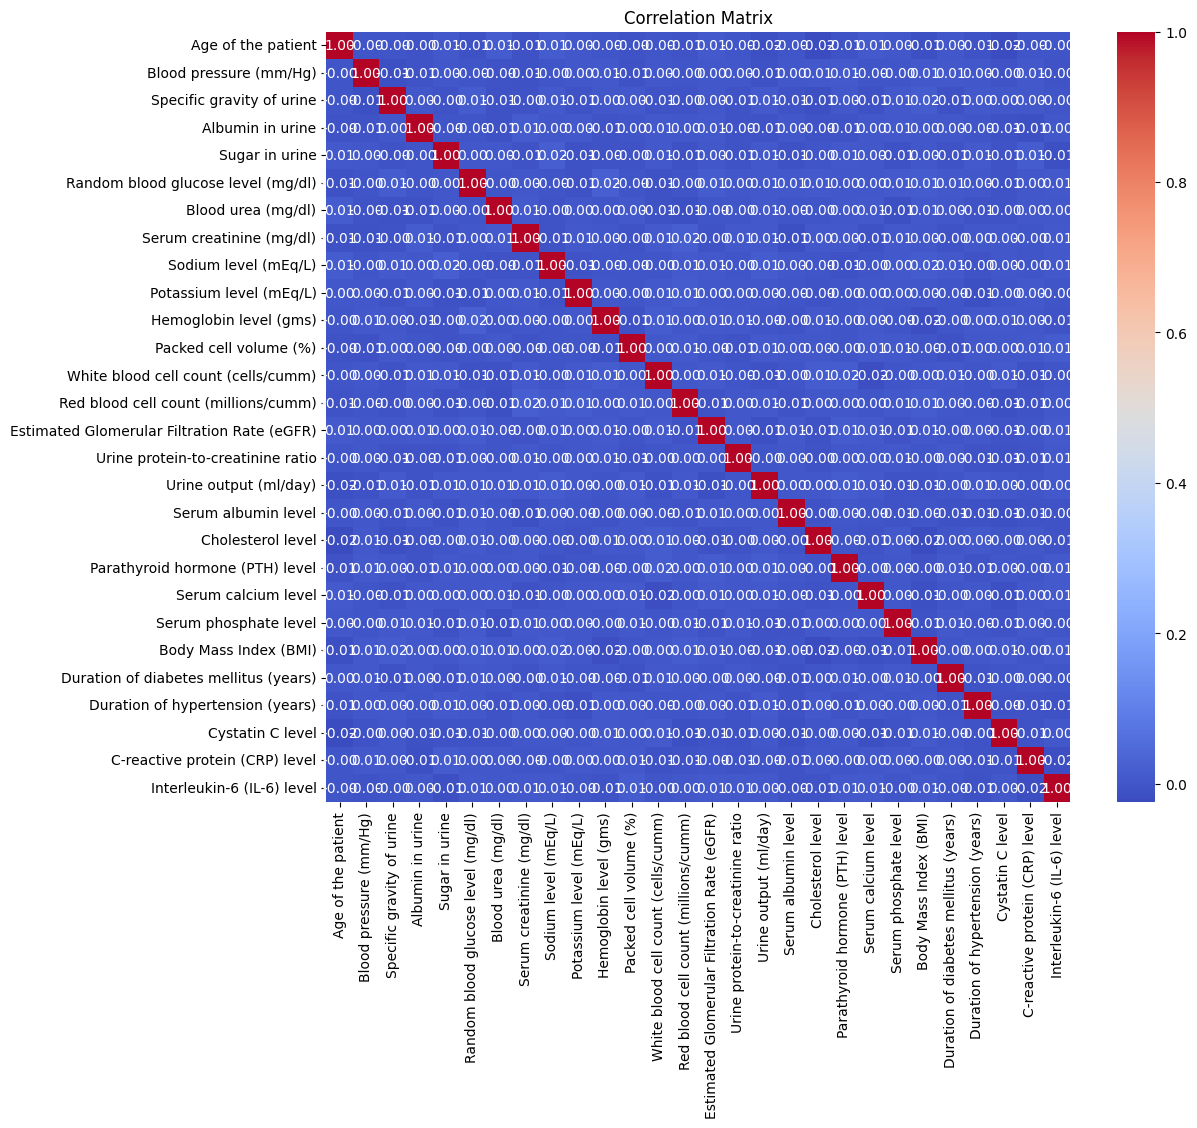

In [17]:
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


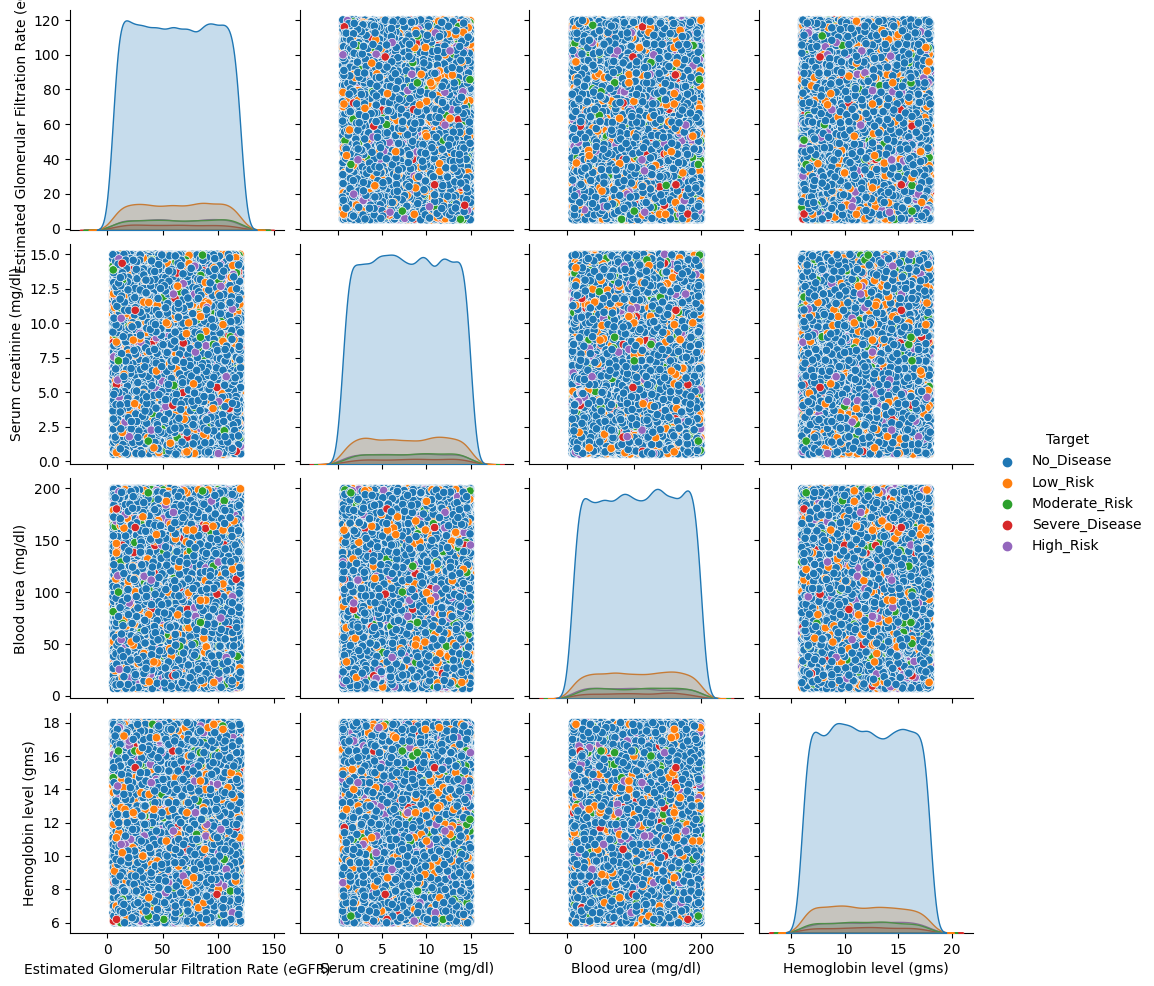

In [18]:
sns.pairplot(
    df,
    hue='Target',
    vars=[
        'Estimated Glomerular Filtration Rate (eGFR)',
        'Serum creatinine (mg/dl)',
        'Blood urea (mg/dl)',
        'Hemoglobin level (gms)'
    ]
)
plt.show()


## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [20]:
features = [
    'Age of the patient', 'Blood pressure (mm/Hg)', 'Serum creatinine (mg/dl)',
    'Blood urea (mg/dl)', 'Sodium level (mEq/L)', 'Potassium level (mEq/L)',
    'Hemoglobin level (gms)', 'Estimated Glomerular Filtration Rate (eGFR)', 
    'Body Mass Index (BMI)'
]

target = 'Target'


In [21]:
df_model = df[features + [target]].dropna()

# Encode target
le = LabelEncoder()
df_model[target] = le.fit_transform(df_model[target])

In [22]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    print(f'{name} Accuracy: {acc:.2f}%')

Logistic Regression Accuracy: 80.23%
Random Forest Accuracy: 80.23%
Decision Tree Accuracy: 62.71%
SVM Accuracy: 80.23%
KNN Accuracy: 76.92%
Naive Bayes Accuracy: 80.23%


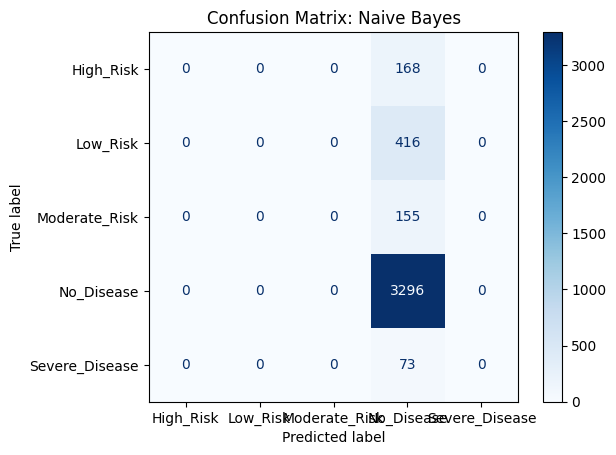

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix: {name}')
plt.show()

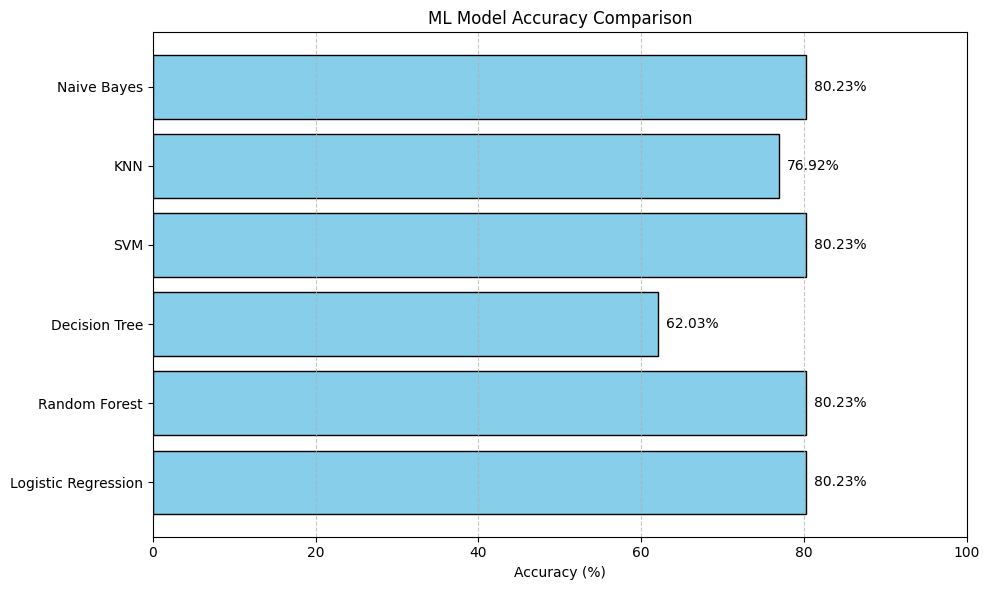

In [25]:
# Accuracy data
model_names = [
    'Logistic Regression', 'Random Forest', 'Decision Tree',
    'SVM', 'KNN', 'Naive Bayes'
]
accuracies = [80.23, 80.23, 62.03, 80.23, 76.92, 80.23]

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.barh(model_names, accuracies, color='skyblue', edgecolor='black')

# Add accuracy labels to bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{acc:.2f}%', va='center')

plt.xlabel('Accuracy (%)')
plt.title('ML Model Accuracy Comparison')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## THank you..pls upvote